# WriteLens - Model Training

Training + evaluasi beberapa model, pilih yang terbaik buat deploy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
import os
import shutil
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)
warnings.filterwarnings('ignore')

Load features_final.csv: 74.866 baris, 12 fitur terpilih dari feature engineering.

In [2]:
df = pd.read_csv("features_final.csv")
feature_cols = [c for c in df.columns if c not in ('label', 'dataset')]
print(df.shape, len(feature_cols), "fitur")
df['label'].value_counts()

(74866, 14) 12 fitur


label
0    42371
1    32495
Name: count, dtype: int64

## Split + Scaling

Dua skenario: Combined (semua) vs DAIGT only (lebih match sama target user).

In [3]:
X_all = df[feature_cols]
y_all = df['label']

daigt_mask = df['dataset'] == 'daigt_v2'
X_daigt = df.loc[daigt_mask, feature_cols].reset_index(drop=True)
y_daigt = df.loc[daigt_mask, 'label'].reset_index(drop=True)

# 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_daigt, y_daigt, test_size=0.2, random_state=42, stratify=y_daigt)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scaler_d = StandardScaler()
X_train_d_sc = scaler_d.fit_transform(X_train_d)
X_test_d_sc  = scaler_d.transform(X_test_d)

print(f"Combined: {X_train_sc.shape} train, {X_test_sc.shape} test")
print(f"DAIGT:    {X_train_d_sc.shape} train, {X_test_d_sc.shape} test")

Combined: (59892, 12) train, (14974, 12) test
DAIGT:    (35892, 12) train, (8974, 12) test


Empat model yang diuji: Logistic Regression, Random Forest, SVM (RBF), Gradient Boosting.
Semua pakai class_weight='balanced'. SVM di-subsample 10.000 baris karena kompleksitas O(n^2).

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
}

# SVM subsample karena O(n^2)
def svm_subsample(X, y, n=10000, seed=42):
    y_arr = np.asarray(y)
    rng = np.random.RandomState(seed)
    idx_h = np.where(y_arr == 0)[0]
    idx_a = np.where(y_arr == 1)[0]
    per = n // 2
    sel = np.concatenate([
        rng.choice(idx_h, min(per, len(idx_h)), replace=False),
        rng.choice(idx_a, min(per, len(idx_a)), replace=False)
    ])
    rng.shuffle(sel)
    return X[sel], y_arr[sel]

## Training

Setiap model di-fit lalu dievaluasi dengan 5-fold cross-validation (F1) dan test set (accuracy, precision, recall, F1, AUC).

In [5]:
def train_and_eval(models_dict, X_train, y_train, X_test, y_test, label=""):
    results = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models_dict.items():
        if name == "SVM (RBF)":
            X_fit, y_fit = svm_subsample(X_train, y_train, n=10000)
            cv_use = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        else:
            X_fit, y_fit = X_train, y_train
            cv_use = cv

        model.fit(X_fit, y_fit)
        cv_scores = cross_val_score(model, X_fit, y_fit, cv=cv_use, scoring='f1', n_jobs=-1)

        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        acc  = accuracy_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)
        auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan')

        results.append({
            "model": name, "cv_f1_mean": cv_scores.mean(), "cv_f1_std": cv_scores.std(),
            "accuracy": acc, "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred), "f1": f1, "roc_auc": auc,
        })
        print(f"  {name}: CV F1={cv_scores.mean():.4f}(+/-{cv_scores.std():.4f}), Test F1={f1:.4f}, AUC={auc:.4f}")

    return results

In [6]:
print("=== Combined ===")
results_combined = train_and_eval(models, X_train_sc, y_train, X_test_sc, y_test)

=== Combined ===
  Logistic Regression: CV F1=0.7563(+/-0.0027), Test F1=0.7517, AUC=0.8444
  Random Forest: CV F1=0.8365(+/-0.0030), Test F1=0.8328, AUC=0.9419
  SVM (RBF): CV F1=0.8442(+/-0.0040), Test F1=0.8327, AUC=0.9338
  Gradient Boosting: CV F1=0.8382(+/-0.0036), Test F1=0.8366, AUC=0.9424


In [7]:
print("=== DAIGT Only ===")
models_daigt = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
}
results_daigt = train_and_eval(models_daigt, X_train_d_sc, y_train_d, X_test_d_sc, y_test_d)

=== DAIGT Only ===
  Logistic Regression: CV F1=0.8989(+/-0.0033), Test F1=0.8941, AUC=0.9743
  Random Forest: CV F1=0.9229(+/-0.0018), Test F1=0.9239, AUC=0.9849
  SVM (RBF): CV F1=0.9466(+/-0.0019), Test F1=0.9285, AUC=0.9860
  Gradient Boosting: CV F1=0.9318(+/-0.0028), Test F1=0.9316, AUC=0.9868


## Perbandingan

Tabel metrik lengkap dan bar chart F1 untuk semua model di kedua skenario.

In [8]:
df_comb  = pd.DataFrame(results_combined)
df_daigt = pd.DataFrame(results_daigt)
print("Combined:")
print(df_comb.to_string(index=False))
print()
print("DAIGT Only:")
print(df_daigt.to_string(index=False))

Combined:
              model  cv_f1_mean  cv_f1_std  accuracy  precision   recall       f1  roc_auc
Logistic Regression    0.756284   0.002739  0.782556   0.745125 0.758424 0.751716 0.844446
      Random Forest    0.836464   0.002989  0.860091   0.864932 0.803047 0.832841 0.941860
          SVM (RBF)    0.844216   0.004039  0.853680   0.826364 0.839206 0.832735 0.933803
  Gradient Boosting    0.838231   0.003564  0.862295   0.862441 0.812279 0.836609 0.942352

DAIGT Only:
              model  cv_f1_mean  cv_f1_std  accuracy  precision   recall       f1  roc_auc
Logistic Regression    0.898925   0.003346  0.915199   0.871003 0.918548 0.894144 0.974268
      Random Forest    0.922939   0.001832  0.941275   0.933236 0.914833 0.923943 0.984893
          SVM (RBF)    0.946638   0.001864  0.943169   0.911368 0.946270 0.928491 0.986043
  Gradient Boosting    0.931809   0.002812  0.946735   0.933429 0.929694 0.931558 0.986752


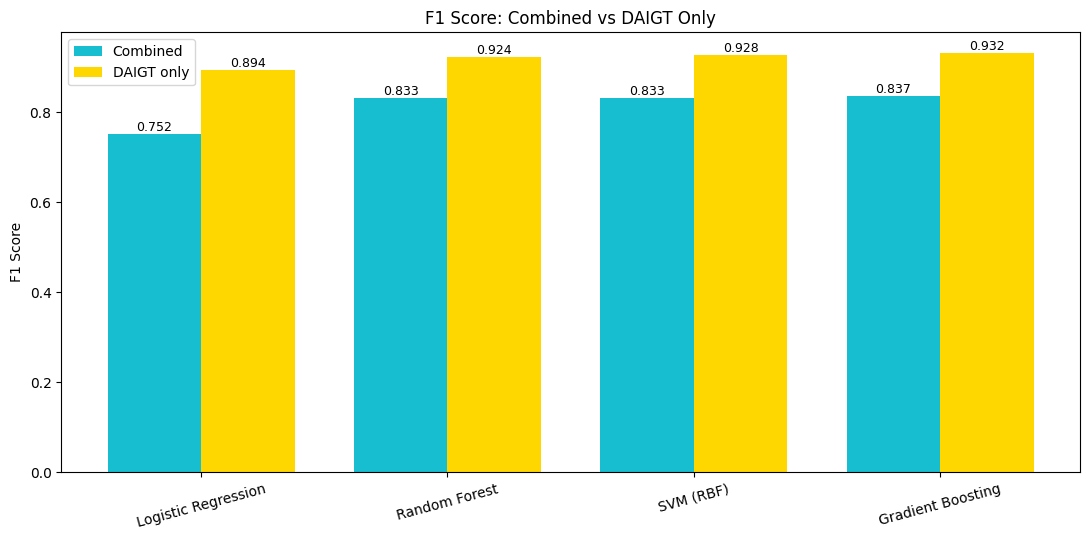

In [9]:
names = df_comb['model'].tolist()
x = np.arange(len(names))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))
b1 = ax.bar(x - w/2, df_comb['f1'],  w, color='tab:cyan', label='Combined')
b2 = ax.bar(x + w/2, df_daigt['f1'], w, color='gold', label='DAIGT only')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score: Combined vs DAIGT Only")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# GB DAIGT menang, pake itu
best_name = "Gradient Boosting"
final_model  = models_daigt[best_name]
final_scaler = scaler_d
final_X_test = X_test_d_sc
final_y_test = y_test_d
print(f"Final: {best_name}, DAIGT only")

Final: Gradient Boosting, DAIGT only


Gradient Boosting DAIGT only dipilih -- F1 0.9316, AUC 0.9868, tertinggi di antara semua model.

## Evaluasi Final

Confusion matrix, classification report, feature importance, dan ROC curve untuk model final.

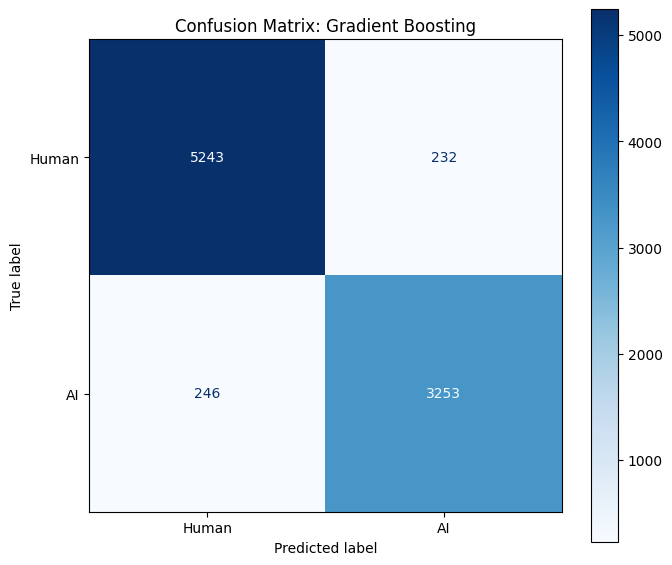

              precision    recall  f1-score   support

       Human       0.96      0.96      0.96      5475
          AI       0.93      0.93      0.93      3499

    accuracy                           0.95      8974
   macro avg       0.94      0.94      0.94      8974
weighted avg       0.95      0.95      0.95      8974



In [11]:
y_pred_final = final_model.predict(final_X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(final_y_test, y_pred_final,
    display_labels=["Human", "AI"], cmap="Blues", ax=ax)
ax.set_title(f"Confusion Matrix: {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(final_y_test, y_pred_final, target_names=["Human", "AI"]))

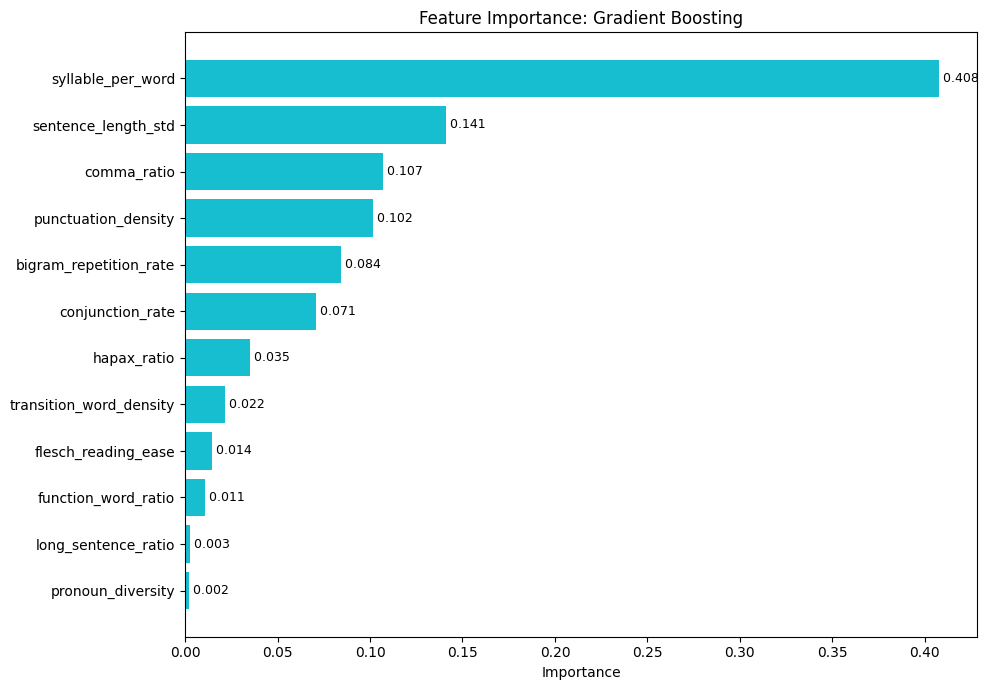

In [12]:
# feature importance
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['feature'], imp_df['importance'], color='tab:cyan')
for i, v in enumerate(imp_df['importance'].values):
    ax.text(v, i, f" {v:.3f}", va='center', fontsize=9)
ax.set_title(f"Feature Importance: {best_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

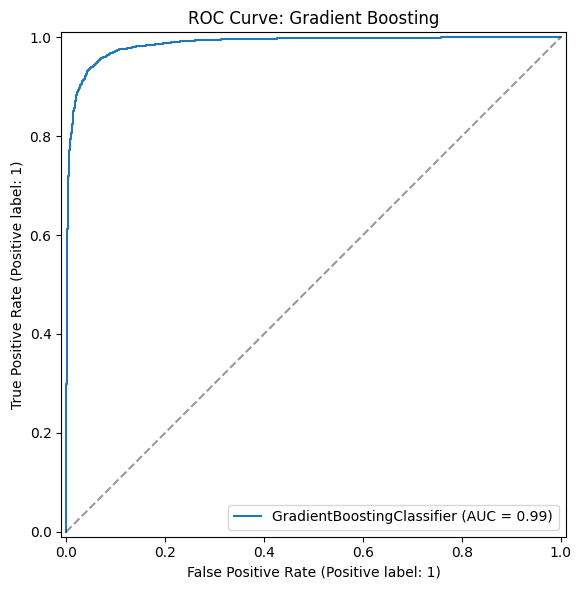

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(final_model, final_X_test, final_y_test, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title(f"ROC Curve: {best_name}")
plt.tight_layout()
plt.show()

## Save

Simpan model.pkl, scaler.pkl, feature_order.json. Copy feature_ranges.json ke folder backend.

In [18]:
os.makedirs("model", exist_ok=True)

joblib.dump(final_model, "model.pkl")
joblib.dump(final_scaler, "scaler.pkl")

with open("feature_order.json", "w") as f:
    json.dump(feature_cols, f)

shutil.copy("feature_ranges.json", "backend/ml/feature_ranges.json")
print("saved to backend/ml/")

saved to backend/ml/


In [20]:
# verify load
loaded = joblib.load("model.pkl")
sample = final_X_test[:1]
print(f"original: {final_model.predict(sample)[0]}, loaded: {loaded.predict(sample)[0]}")
print(f"proba: {loaded.predict_proba(sample)[0]}")

original: 0, loaded: 0
proba: [0.99395061 0.00604939]



**Model terpilih.** Gradient Boosting yang ditrain di DAIGT v2 only (essay mahasiswa). Dipilih karena F1 dan AUC paling tinggi di antara empat kandidat, gap CV vs test kecil, dan domain-nya match sama target user WriteLens.

**Performa.** F1 sekitar 0.93, accuracy sekitar 0.95, AUC sekitar 0.99 di test set DAIGT. Angka pastinya ada di tabel Section 7 dan classification report Section 10. Cukup bagus buat baseline klasifikasi human vs AI pakai fitur stylometric doang.

**Dataset.** Combined (DAIGT + MAGE) vs DAIGT only ternyata selisihnya cukup besar. F1 DAIGT only 0.93 sementara Combined cuma 0.84. Yang dicemasin di EDA terbukti: domain MAGE (teks pendek Reddit/Yelp/QA) bikin sinyal stylometric jadi noisy. Buat WriteLens yang target user-nya orang nulis essay/artikel formal, DAIGT only justru lebih sesuai secara metric maupun konteks.

**Top fitur dari model.** Menurut feature importance GB, yang paling kuat adalah `syllable_per_word`, `sentence_length_std`, `comma_ratio`, `punctuation_density`, dan `bigram_repetition_rate`. Ada perbedaan sedikit sama ranking Cohen's d (yang lebih nguatin `function_word_ratio` dan `transition_word_density`), tapi overall masih overlap. List ini yang akan dipake buat nentuin 6-8 fitur yang ditampilin di UI WriteLens.

**Bandingan model.** Logistic Regression jauh lebih lemah (sinyalnya non-linear). Random Forest dan SVM mepet sama GB tapi sedikit di bawah. SVM kita sub-sample training-nya ke 10K biar kompleksitasnya nggak meledak, jadi bukan apple-to-apple full data.

**Output.** Model + scaler + feature order + feature ranges udah di-save ke `backend/ml/`. Tinggal di-load sama FastAPI di service prediksi.